In [85]:
import pandas as pd
import os
import warnings
import matplotlib.pyplot as plt

### Analysis on Georgia Road Inventory Data

In [67]:

path = "GDOR_Road_Inventory_2024/SURFACE_TYPE.csv"
print("File exists:", os.path.exists(path))

warnings.filterwarnings("ignore")

File exists: True


In [66]:
df_Gdot = pd.read_csv("GDOR_Road_Inventory_2024/SURFACE_TYPE.csv")

In [52]:
print(df_Gdot.dtypes)

OID                       int64
RouteId                  object
BeginPoint              float64
EndPoint                float64
SURFACE_TYPEVn          float64
SURFACE_TYPEVt          float64
SURFACE_TYPEVd           object
SURFACE_TYPEComments     object
Shape_Length            float64
dtype: object


In [53]:
display(df_Gdot.dropna(how='all').tail())

,OID,RouteId,BeginPoint,EndPoint,SURFACE_TYPEVn,SURFACE_TYPEVt,SURFACE_TYPEVd,SURFACE_TYPEComments,Shape_Length
100442,-1,1313200125103INC,0.600,0.700,2.0,NaN,1/1/2024,GA3130356-01,0.001458
100443,-1,1303200034900INC,6.400,6.500,2.0,NaN,1/1/2024,GA3030201-01,0.001712
100444,-1,13011000017COINC,4.532,4.632,2.0,NaN,1/1/2024,GA3010132-01,0.001561
100445,-1,1313200078703INC,0.681,0.781,2.0,NaN,1/1/2024,GA3130382-01,0.001451
100446,-1,1313200028201INC,1.100,1.200,2.0,NaN,1/1/2024,GA3137669-01,0.001722


In [81]:
df_Gdot['SURFACE_TYPEVt'].isnull().value_counts()
# SURFACE_TYPEVt column is null. Remove during DataCleaning

SURFACE_TYPEVt
True    100447
Name: count, dtype: int64

In [84]:
df_Gdot['SURFACE_NAME'].value_counts()
# SURFACE_TYPEVt column is null. Remove during DataCleaning

SURFACE_NAME
Bituminous       89661
JPCP Concrete     7655
AC Overlay        1606
CRCP Concrete     1517
Unpaved              8
Name: count, dtype: int64

In [90]:
df_Gdot.info

<bound method DataFrame.info of         OID           RouteId  BeginPoint  EndPoint  SURFACE_TYPEVn  \
0        -1  1000100000300INC     141.940   142.040             2.0   
1        -1  1000100000200INC     132.270   132.370             2.0   
2        -1  1000100000300INC     199.240   199.340             2.0   
3        -1  1000100000300INC     277.440   277.540             2.0   
4        -1  1000100000200INC     144.420   144.520             2.0   
...     ...               ...         ...       ...             ...   
100442   -1  1313200125103INC       0.600     0.700             2.0   
100443   -1  1303200034900INC       6.400     6.500             2.0   
100444   -1  13011000017COINC       4.532     4.632             2.0   
100445   -1  1313200078703INC       0.681     0.781             2.0   
100446   -1  1313200028201INC       1.100     1.200             2.0   

        SURFACE_TYPEVt SURFACE_TYPEVd SURFACE_TYPEComments  Shape_Length  \
0                  NaN     12/16/2024  

#### Total Segment Miles

In [55]:
# calcuating Total Segment Miles
df_Gdot['Seg_miles'] = df_Gdot['EndPoint'] - df_Gdot['BeginPoint']
print(df_Gdot['Seg_miles'].sum(), "Segment miles")

9109.636799999998 Segment miles


From 
13.4 Codes
Table 14. Surface Types
Code Description
1 Unpaved
2 Bituminous
3 JPCP—Jointed Plain Concrete
Pavement (includes whitetopping)
5 CRCP—Continuously Reinforced
Concrete Pavement
7 AC Overlay over Existing Jointed
Concrete Pavement

 ### Statewide pavement breakdown: How many miles of each type?

In [35]:
df_Gdot['SURFACE_TYPEVn'].value_counts()

SURFACE_TYPEVn
2.0     89661
3.0      7655
7.0      1606
5.0      1517
11.0        8
Name: count, dtype: int64

<Axes: ylabel='SURFACE_TYPEVn'>

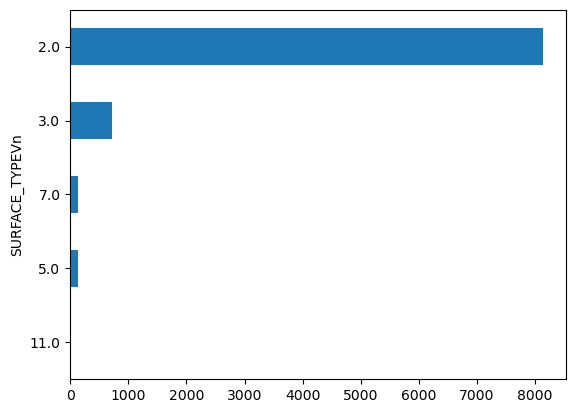

In [62]:
df_Gdot.groupby('SURFACE_TYPEVn')['Seg_miles'].sum().sort_values().plot(kind='barh')

In [68]:
df_Gdot['SEG_MILES'] = df_Gdot['EndPoint'] - df_Gdot['BeginPoint']
df_Gdot['SURFACE_NAME'] = df_Gdot['SURFACE_TYPEVn'].map({
    11: 'Unpaved',
    2: 'Bituminous', 3: 'JPCP Concrete', 5: 'CRCP Concrete', 
    7: 'AC Overlay'
}).fillna('Other')

pivot = pd.pivot_table(
    df_Gdot, 
    values='SEG_MILES',
    index='RouteId',
    columns='SURFACE_NAME',
    aggfunc='sum',
    fill_value=0
).round(2)

print(pivot.tail(10))  # last 10 routes

SURFACE_NAME      AC Overlay  Bituminous  CRCP Concrete  JPCP Concrete  \
RouteId                                                                  
1313200121103INC         0.0        0.78            0.0            0.0   
1313200121203INC         0.0        0.95            0.0            0.0   
1313200121503INC         0.0        2.50            0.0            0.0   
1313200125103INC         0.0        1.46            0.0            0.0   
1319200072407INC         0.0        1.06            0.0            0.0   
1321200068905INC         0.0        1.08            0.0            0.0   
1321200072609INC         0.0        0.61            0.0            0.0   
5085100105300INC         0.0        0.03            0.0            0.0   
5095100000100INC         0.0        0.25            0.0            0.0   
5151100213800INC         0.0        0.02            0.0            0.0   

SURFACE_NAME      Unpaved  
RouteId                    
1313200121103INC      0.0  
1313200121203INC      0.0  

In [75]:
df_Gdot[df_Gdot['SURFACE_TYPEVn'] == 11]

,OID,RouteId,BeginPoint,EndPoint,SURFACE_TYPEVn,SURFACE_TYPEVt,SURFACE_TYPEVd,SURFACE_TYPEComments,Shape_Length,SEG_MILES,SURFACE_NAME
11649,-1,1000100001100INC,87.3600,87.4400,11.0,NaN,12/14/2024,NaN,0.001161,0.0800,Unpaved
75828,-1,1275200082317INC,1.7898,1.8300,11.0,NaN,12/9/2024,NaN,0.000642,0.0402,Unpaved
77087,-1,1275200082317INC,1.9899,1.9900,11.0,NaN,12/9/2024,NaN,0.000002,0.0001,Unpaved
77207,-1,1275200082317INC,1.8900,1.9899,11.0,NaN,12/9/2024,NaN,0.001593,0.0999,Unpaved
77667,-1,1275200082317INC,1.8405,1.8900,11.0,NaN,12/9/2024,NaN,0.000790,0.0495,Unpaved
78219,-1,1275200082317INC,1.7300,1.7898,11.0,NaN,12/9/2024,NaN,0.000952,0.0598,Unpaved
78340,-1,1275200082317INC,1.6300,1.7300,11.0,NaN,12/9/2024,NaN,0.001501,0.1000,Unpaved
78835,-1,1275200082317INC,1.8300,1.8405,11.0,NaN,12/9/2024,NaN,0.000168,0.0105,Unpaved


In [60]:
# Milepost range pivot - where each surface type runs
pivot_range = df_Gdot.groupby(['RouteId','SURFACE_NAME']).agg(
    Start_MP=('BeginPoint','min'),
    End_MP=('EndPoint','max'),
    Total_Miles=('SEG_MILES','sum')
).round(2)

print(pivot_range.tail(15))

                                Start_MP  End_MP  Total_Miles
RouteId          SURFACE_NAME                                
1313200101603INC AC Overlay          0.0    0.36         0.26
                 CRCP Concrete       0.2    0.30         0.10
1313200106103INC Bituminous          0.0    2.60         2.60
1313200117700INC Bituminous          0.0    4.38         4.38
1313200118703INC Bituminous          1.5    1.55         0.05
1313200121103INC Bituminous          0.0    0.78         0.78
1313200121203INC Bituminous          1.3    2.25         0.95
1313200121503INC Bituminous          0.0    3.38         2.50
1313200125103INC Bituminous          0.0    1.46         1.46
1319200072407INC Bituminous          0.0    1.06         1.06
1321200068905INC Bituminous          0.0    1.08         1.08
1321200072609INC Bituminous          0.0    0.61         0.61
5085100105300INC Bituminous          0.0    0.03         0.03
5095100000100INC Bituminous          0.0    0.25         0.25
51511002

In [87]:
# Statewide pavement breakdown: How many miles of each type

Total miles: 9109.6

Breakdown:
SURFACE_NAME
Unpaved             0.44
CRCP Concrete     125.27
AC Overlay        138.42
JPCP Concrete     716.13
Bituminous       8129.38
Name: SEG_MILES, dtype: float64


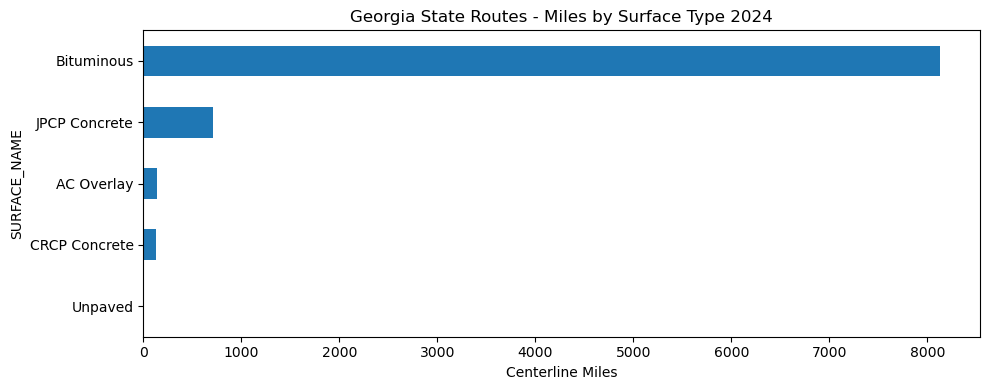

In [86]:
miles_by_type = df_Gdot.query("SEG_MILES > 0").groupby('SURFACE_NAME')['SEG_MILES'].sum().sort_values()

print("Total miles:", miles_by_type.sum().round(1))
print("\nBreakdown:")
print(miles_by_type.round(2))

miles_by_type.plot(kind='barh', figsize=(10,4))
plt.title('Georgia State Routes - Miles by Surface Type 2024')
plt.xlabel('Centerline Miles')
plt.tight_layout()
plt.show()

In [88]:
print(df_Gdot.dtypes)

OID                       int64
RouteId                  object
BeginPoint              float64
EndPoint                float64
SURFACE_TYPEVn          float64
SURFACE_TYPEVt          float64
SURFACE_TYPEVd           object
SURFACE_TYPEComments     object
Shape_Length            float64
SEG_MILES               float64
SURFACE_NAME             object
dtype: object


In [89]:
df_Gdot.nlargest(10, 'SEG_MILES')[['RouteId','BeginPoint','EndPoint','SURFACE_TYPEVt','SURFACE_TYPEVd','SEG_MILES']]

,RouteId,BeginPoint,EndPoint,SURFACE_TYPEVt,SURFACE_TYPEVd,SEG_MILES
80532,1000100009100INC,73.2900,73.4000,NaN,12/15/2024,0.1100
79709,1000100000900INC,74.2253,74.3346,NaN,12/4/2024,0.1093
83659,1000100003500INC,75.2499,75.3536,NaN,12/22/2024,0.1037
81073,1000100009300INC,10.0249,10.1266,NaN,3/28/2023,0.1017
3,1000100000300INC,277.4400,277.5400,NaN,11/23/2024,0.1000
4,1000100000200INC,144.4200,144.5200,NaN,12/5/2024,0.1000
7,1000100000300INC,252.6400,252.7400,NaN,11/30/2024,0.1000
13,1000100000100INC,76.2400,76.3400,NaN,12/14/2024,0.1000
17,1000100000300INC,162.9500,163.0500,NaN,11/27/2024,0.1000
19,1000100000100INC,259.0600,259.1600,NaN,12/4/2024,0.1000


In [98]:
df_Gdot['segment_miles'] = df_Gdot['EndPoint'] - df_Gdot['BeginPoint']
longest = df_Gdot.loc[df_Gdot.groupby('SURFACE_TYPEVn')['segment_miles'].idxmax()]
longest[['RouteId', 'BeginPoint', 'EndPoint', 'SURFACE_TYPEVn', 'segment_miles']]

,RouteId,BeginPoint,EndPoint,SURFACE_TYPEVn,segment_miles
80532,1000100009100INC,73.29,73.40,2.0,0.11
359,1000100000300INC,331.33,331.43,3.0,0.10
1063,1000100000300INC,276.51,276.61,5.0,0.10
85,1000100000300INC,172.98,173.08,7.0,0.10
78340,1275200082317INC,1.63,1.73,11.0,0.10


In [102]:
route = '1000100009100INC'
route_df = df_Gdot[df_Gdot['RouteId'] == route].copy()
route_df['segment_miles'] = route_df['EndPoint'] - route_df['BeginPoint']

profile = (route_df.groupby('SURFACE_TYPEVn')['segment_miles']
           .sum()
           .reset_index())
profile['percent'] = 100 * profile['segment_miles'] / profile['segment_miles'].sum()
profile.sort_values('percent', ascending=False)

,SURFACE_TYPEVn,segment_miles,percent
0,2.0,4.6458,95.872715
1,5.0,0.2000,4.127285


In [114]:
ga400_routes = df_Gdot[df_Gdot['RouteId'].str.contains('0400', na=False)]
ga400_routes

,OID,RouteId,BeginPoint,EndPoint,SURFACE_TYPEVn,SURFACE_TYPEVt,SURFACE_TYPEVd,SURFACE_TYPEComments,Shape_Length,SEG_MILES,SURFACE_NAME,segment_miles
368,-1,1000100000400INC,218.26,218.3000,2.0,NaN,12/4/2024,NaN,0.000671,0.0400,Bituminous,0.0400
2559,-1,1000100000400INC,224.34,224.3440,5.0,NaN,12/4/2024,NaN,0.000059,0.0040,CRCP Concrete,0.0040
3024,-1,1000100000400INC,169.13,169.2300,2.0,NaN,11/30/2024,NaN,0.001458,0.1000,Bituminous,0.1000
3071,-1,1000100000400INC,127.22,127.3200,2.0,NaN,11/30/2024,NaN,0.001482,0.1000,Bituminous,0.1000
4131,-1,1000100000400INC,152.72,152.8200,2.0,NaN,11/30/2024,NaN,0.001523,0.1000,Bituminous,0.1000
...,...,...,...,...,...,...,...,...,...,...,...,...
99513,-1,1277200020400INC,2.66,2.6645,2.0,NaN,12/20/2024,GA2770423-02,0.000076,0.0045,Bituminous,0.0045
99568,-1,1215200210400INC,2.30,2.4000,2.0,NaN,1/1/2024,GA2150632-01,0.001709,0.1000,Bituminous,0.1000
99580,-1,1139200130400INC,1.90,2.0000,2.0,NaN,1/1/2024,GA1390556-01,0.001658,0.1000,Bituminous,0.1000
99587,-1,1215200210400INC,1.70,1.8000,2.0,NaN,1/1/2024,GA2150632-01,0.001714,0.1000,Bituminous,0.1000


In [116]:
print(df_Gdot['RouteId'].unique())

['1000100000300INC' '1000100000200INC' '1000100000100INC' ...
 '1313200067800INC' '1313200024100INC' '1299200090005INC']


### NHS

In [132]:
df_Nhs = pd.read_csv("GDOR_Road_Inventory_2024/NHS.csv")

In [121]:
df_Nhs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 807 entries, 0 to 806
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OID           807 non-null    int64  
 1   RouteId       807 non-null    object 
 2   BeginPoint    807 non-null    float64
 3   EndPoint      807 non-null    float64
 4   NHSVn         807 non-null    float64
 5   NHSVt         807 non-null    object 
 6   NHSComments   0 non-null      float64
 7   NHSVd         0 non-null      float64
 8   Shape_Length  807 non-null    float64
dtypes: float64(6), int64(1), object(2)
memory usage: 56.9+ KB


In [124]:
df_Nhs.isnull().sum()

OID               0
RouteId           0
BeginPoint        0
EndPoint          0
NHSVn             0
NHSVt             0
NHSComments     807
NHSVd           807
Shape_Length      0
dtype: int64

In [127]:
print(len(df_Nhs))df_Nhs.index.size

807

##### NHSComments and NHSVd are null

In [133]:
df_Nhs.tail()

,OID,RouteId,BeginPoint,EndPoint,NHSVn,NHSVt,NHSComments,NHSVd,Shape_Length
802,-1,1000100002400INC,159.4049,199.7315,1.0,4 - Non-Int. NHS (mainline),NaN,NaN,0.618811
803,-1,1067200784900INC,0.0000,0.1456,1.0,4 - Non-Int. NHS (mainline),NaN,NaN,0.002398
804,-1,1000100014200INC,30.5270,31.5692,1.0,4 - Non-Int. NHS (mainline),NaN,NaN,0.015868
805,-1,1000100001600INC,37.6798,38.3055,1.0,4 - Non-Int. NHS (mainline),NaN,NaN,0.009248
806,-1,1000100004100INC,15.3375,16.2732,1.0,4 - Non-Int. NHS (mainline),NaN,NaN,0.014799


In [134]:
df_Nhs['NHSVt'].value_counts()

NHSVt
4 - Non-Int. NHS (mainline)         566
5 - NHS Connector                   128
1 - Interstate                       50
2 - Non-int. STRAHNET (mainline)     43
3 - STRAHNET Connector               20
Name: count, dtype: int64

In [137]:
df_UrbanId = pd.read_csv("GDOR_Road_Inventory_2024/URBAN_ID.csv")
df_UrbanId.tail(5)

,OID,RouteId,BeginPoint,EndPoint,URBAN_IDVn,URBAN_IDVt,URBAN_IDVd,URBAN_IDComments,Shape_Length
209429,-1,22171088402B0INC,0.0,0.1804,3817.0,NaN,NaN,Based on 2020 AUABs rather than past 2010 AUABs,0.003119
209430,-1,5171200000100INC,0.0,0.0747,99998.0,NaN,NaN,Based on 2020 AUABs rather than past 2010 AUABs,0.001194
209431,-1,22951027001E0INC,0.0,0.7482,15832.0,NaN,NaN,Based on 2020 AUABs rather than past 2010 AUABs,0.011594
209432,-1,22831071404C0INC,0.0,0.3058,99999.0,NaN,NaN,Based on 2020 AUABs rather than past 2010 AUABs,0.005142
209433,-1,21511228401D0INC,0.0,0.3940,3817.0,NaN,NaN,Based on 2020 AUABs rather than past 2010 AUABs,0.006744


In [140]:
print(df_UrbanId['URBAN_IDVn'].value_counts())

URBAN_IDVn
3817.0     78526
99999.0    72330
99998.0    21486
4222.0      5498
79768.0     4781
32194.0     3338
52822.0     3087
19099.0     3078
91783.0     2723
3763.0      2412
15832.0     1692
76204.0     1521
901.0       1486
22069.0     1449
11026.0     1432
89974.0     1375
96130.0     1179
14185.0     1155
39133.0      886
Name: count, dtype: int64


In [149]:
print(len(df_UrbanId['URBAN_IDVn'].unique()))

19


## Area of the Urban Areas 

In [157]:
df_UrbanId['segment_miles'] = df_UrbanId['EndPoint'] - df_UrbanId['BeginPoint']
miles_by_urban = (df_UrbanId.groupby('URBAN_IDVn')['segment_miles']
                  .sum()
                  .reset_index(name='centerline_miles')
                  .sort_values('centerline_miles', ascending=False))

#print(miles_by_urban)

urban_names = {
    3817: 'Atlanta, GA',
    99999: 'Rural', 
    99998: 'Rural',
    4222: 'Augusta, GA-SC',
    79768: 'Columbus, GA-AL', 
    32194: 'Macon, GA',
    52822: 'Athens, GA',
    19099: 'Savannah, GA',
    91783: 'Albany, GA',
    3763: 'Chattanooga, TN-GA',
    15832: 'Rome, GA',
    76204: 'Warner Robins, GA',
    901: 'Dalton, GA',
    22069: 'Valdosta, GA',
    11026: 'Gainesville, GA',
    89974: 'Brunswick, GA',
    96130: 'Hinesville, GA',
    14185: 'LaGrange, GA',
    39133: 'Cartersville, GA'
}

df_UrbanId['Urban_Name'] = df_UrbanId['URBAN_IDVn'].map(urban_names)

# Now redo miles with names
miles_by_urban = (df_UrbanId.groupby('Urban_Name')['segment_miles']
                  .sum()
                  .reset_index(name='centerline_miles')
                  .sort_values('centerline_miles', ascending=False))
print(miles_by_urban)

            Urban_Name  centerline_miles
14               Rural        88495.5834
2          Atlanta, GA        25310.2593
3       Augusta, GA-SC         2051.4289
7      Columbus, GA-AL         1664.5924
12           Macon, GA         1097.9061
1           Athens, GA         1096.3035
15        Savannah, GA         1030.5254
6   Chattanooga, TN-GA          882.1686
0           Albany, GA          871.3829
8           Dalton, GA          661.1226
13            Rome, GA          611.1161
9      Gainesville, GA          544.7099
17   Warner Robins, GA          512.0654
16        Valdosta, GA          508.2050
4        Brunswick, GA          471.6362
10      Hinesville, GA          452.5439
11        LaGrange, GA          423.1972
5     Cartersville, GA          267.4781


In [150]:
df_CountyId = pd.read_csv("GDOR_Road_Inventory_2024/COUNTY_ID.csv")
df_CountyId.tail(5)

,OBJECTID,RouteId,BeginPoint,EndPoint,COUNTY_IDVn,COUNTY_IDVt,COUNTY_IDVd,COUNTY_IDComments,Shape_Length
213610,213611,22471084402A0INC,0.0,0.3128,247.0,7,NaN,NaN,0.004945
213611,213612,22151001411F0INC,0.0,0.2134,215.0,3,NaN,NaN,0.003373
213612,213613,22171093402D0INC,0.0,0.2890,217.0,2,NaN,NaN,0.005003
213613,213614,21751054404D0INC,0.0,0.4048,175.0,2,NaN,NaN,0.006889
213614,213615,21391022419E0INC,0.0,0.3214,139.0,1,NaN,NaN,0.004939


## Miles by County

In [158]:
df_CountyId['segment_miles'] = df_CountyId['EndPoint'] - df_CountyId['BeginPoint']
miles_by_county = (df_CountyId.groupby('COUNTY_IDVn')['segment_miles']
                  .sum()
                  .reset_index(name='centerline_miles')
                  .sort_values('centerline_miles', ascending=False))
print(miles_by_county)

     COUNTY_IDVn  centerline_miles
59         121.0         4303.5480
66         135.0         3721.0173
32          67.0         3338.3928
43          89.0         2702.5371
27          57.0         1777.0530
..           ...               ...
49         101.0          250.5633
130        265.0          234.7284
61         125.0          230.9394
117        239.0          198.2884
25          53.0          111.2220

[159 rows x 2 columns]
